In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./placement.csv")

df.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

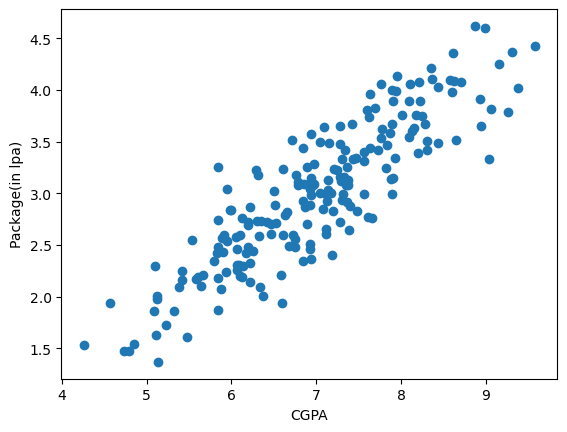

In [3]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [4]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)

LinearRegression()

In [10]:
# predict test
from sklearn.metrics import r2_score
y_pred = lr.predict(X_test)

print(r2_score(y_test,y_pred)*100)


78.0730147510384


In [31]:
# intercept and slope values
print(f"Intercept: {lr.intercept_}")
print(f"Slope: {lr.coef_}")

Intercept: -0.8961119222429144
Slope: [0.55795197]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


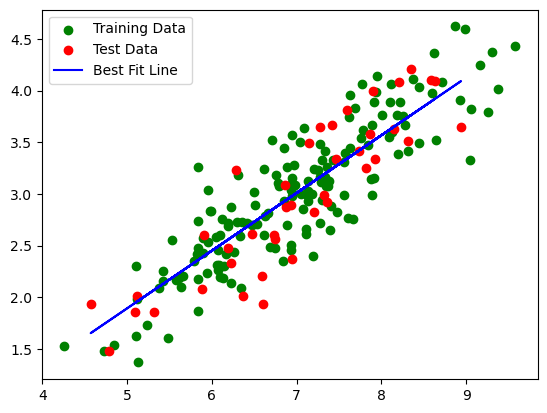

In [14]:
# draw the best fit line 

plt.scatter(X_train, y_train, color='green', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

plt.plot(
    X_test.values.reshape(-1,1),
    lr.predict(X_test.values.reshape(-1,1)),
    color='blue',
    label='Best Fit Line'
)

plt.legend()
plt.show()


In [ ]:
# creating own class of simple linear regression

class SimpleLinearRegression:
    def __init__(self):
        self.b0 = 0
        self.b1 = 0

    def fit(self, X_train, Y_train):
            numerator = 0
            denominator = 0

            mean_x = np.mean(X_train)
            mean_y = np.mean(Y_train)

            for i in range(len(X_train)):
                numerator += (X_train.iloc[i] - mean_x) * (Y_train.iloc[i] - mean_y)
                denominator += (X_train.iloc[i] - mean_x) ** 2

            self.b1 = numerator / denominator
            self.b0 = mean_y - (self.b1 * mean_x)
    def predict(self, X_test):
        return self.b0 + self.b1 * X_test


In [27]:
own_lr = SimpleLinearRegression()

own_lr.fit(X_train,y_train)

y_pred = own_lr.predict(X_test)

print(r2_score(y_test,y_pred)*100)

78.07301475103841


In [ ]:
# X_test.values.reshape(-1,1)

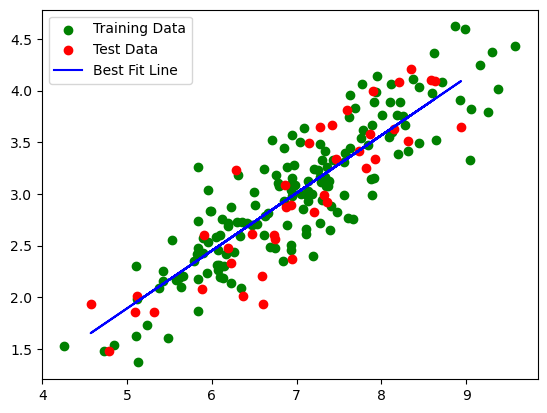

In [30]:
# draw the best fit line 

plt.scatter(X_train, y_train, color='green', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

plt.plot(
    X_test.values.reshape(-1,1),
    own_lr.predict(X_test),
    color='blue',
    label='Best Fit Line'
)

plt.legend()
plt.show()


In [ ]:
# skitlearn Library Result of intercept and slope
# Intercept: -0.8961119222429144
# Slope: [0.55795197]

In [32]:
# own class result of intercept and slope

print(f"Intercept: {own_lr.b0}")
print(f"Slope: {own_lr.b1}")

Intercept: cgpa   -0.896112
Name: 137, dtype: float64
Slope: cgpa    0.557952
Name: 137, dtype: float64
